In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [16]:
df = pd.read_csv("data/historical_sales.csv")

df.head()

,Date,Orders,Customers,Returns,Marketing_Spend,Average_Order_Value,Revenue
0,2019-01-01,357,304,10,19707.31,827.38,135084.72
1,2019-02-01,348,274,16,21411.95,785.72,132435.50
2,2019-03-01,403,300,6,22698.73,755.69,160892.75
3,2019-04-01,415,322,9,22689.56,766.70,189443.53
4,2019-05-01,349,266,12,19575.77,738.18,170476.97


## Data Understanding

In this section, we examine the structure of the dataset, including
the number of rows and columns, column names, data types, and
basic information about the dataset.

In [17]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Shape of dataset: (84, 7)

Column names:
Index(['Date', 'Orders', 'Customers', 'Returns', 'Marketing_Spend',
       'Average_Order_Value', 'Revenue'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 84 non-null     str    
 1   Orders               84 non-null     int64  
 2   Customers            84 non-null     int64  
 3   Returns              84 non-null     int64  
 4   Marketing_Spend      84 non-null     float64
 5   Average_Order_Value  84 non-null     float64
 6   Revenue              84 non-null     float64
dtypes: float64(3), int64(3), str(1)
memory usage: 5.5 KB


In [18]:
df.describe()

,Orders,Customers,Returns,Marketing_Spend,Average_Order_Value,Revenue
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,474.785714,378.273810,12.321429,22943.048452,883.922619,186270.333810
std,76.180362,65.817629,4.296709,4404.979188,71.314159,24871.173098
min,323.000000,252.000000,1.000000,12225.680000,738.180000,131457.850000
25%,413.000000,329.500000,9.750000,19990.407500,829.720000,169150.185000
50%,475.500000,381.000000,12.000000,22962.710000,885.625000,186783.825000
75%,532.500000,416.750000,15.250000,25922.970000,939.455000,203069.947500
max,625.000000,515.000000,22.000000,32030.250000,1030.240000,238936.030000


## Data Cleaning

In this section, the dataset is checked for missing values and duplicate
records. The Date column is also converted into the correct datetime
format to prepare the data for time-based analysis and forecasting.

In [19]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Date                   0
Orders                 0
Customers              0
Returns                0
Marketing_Spend        0
Average_Order_Value    0
Revenue                0
dtype: int64


In [20]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [21]:
print("Missing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df = df.drop_duplicates()

numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

print("\nFinal missing values:")
print(df.isnull().sum())

print("\nData type of Date column:", df["Date"].dtype)

Missing values:
Date                   0
Orders                 0
Customers              0
Returns                0
Marketing_Spend        0
Average_Order_Value    0
Revenue                0
dtype: int64

Number of duplicate rows: 0

Final missing values:
Date                   0
Orders                 0
Customers              0
Returns                0
Marketing_Spend        0
Average_Order_Value    0
Revenue                0
dtype: int64

Data type of Date column: datetime64[us]


In [22]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

print("Final missing values:")
print(df.isnull().sum())

Final missing values:
Date                   0
Orders                 0
Customers              0
Returns                0
Marketing_Spend        0
Average_Order_Value    0
Revenue                0
dtype: int64


## Exploratory Data Analysis

In this section, we analyze the historical sales data using visualizations
to identify revenue trends, monthly patterns, relationships between
variables, and other useful patterns before building the predictive model.

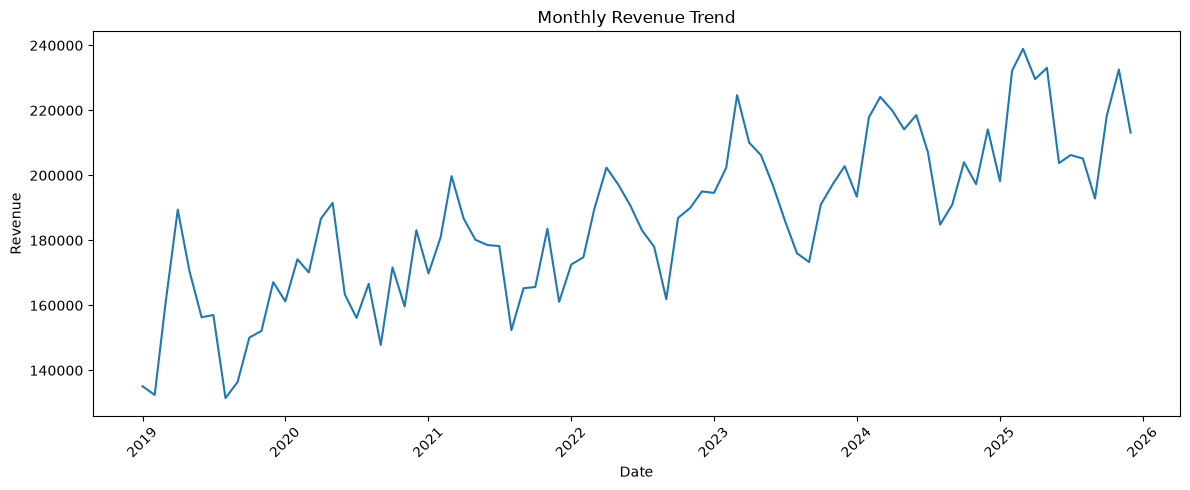

In [23]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Revenue"])

plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Monthly Revenue Analysis

This analysis examines the average revenue generated in each month.
It helps identify monthly patterns and possible seasonal variations
in historical revenue.

In [24]:
df["Month"] = df["Date"].dt.month

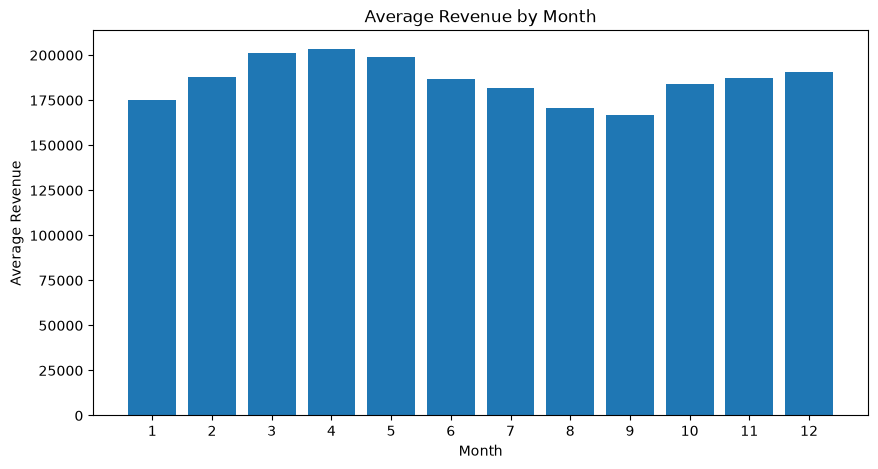

In [25]:
monthly_revenue = df.groupby("Month")["Revenue"].mean()

plt.figure(figsize=(10,5))

plt.bar(monthly_revenue.index, monthly_revenue.values)

plt.title("Average Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")

plt.xticks(range(1,13))

plt.show()

## Orders vs Revenue

This analysis examines the relationship between the number of orders
and revenue. It helps determine whether higher order volumes are
associated with higher revenue.

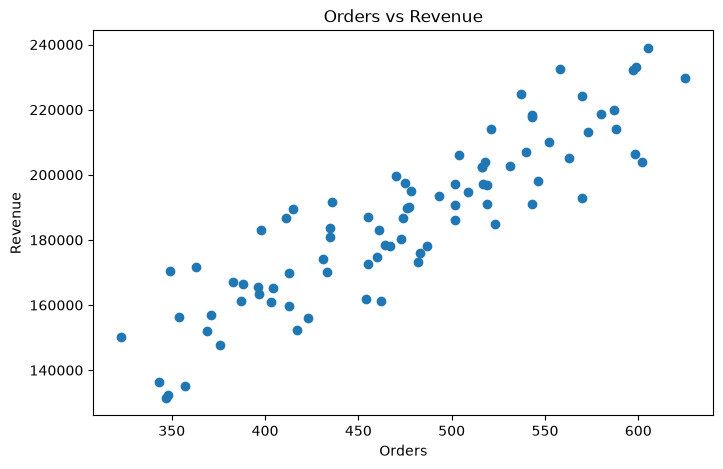

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(df["Orders"], df["Revenue"])

plt.title("Orders vs Revenue")
plt.xlabel("Orders")
plt.ylabel("Revenue")

plt.show()

## Correlation Analysis

Correlation analysis is used to understand the relationships between
the numerical variables in the dataset. It helps identify which
variables may have a stronger relationship with revenue.

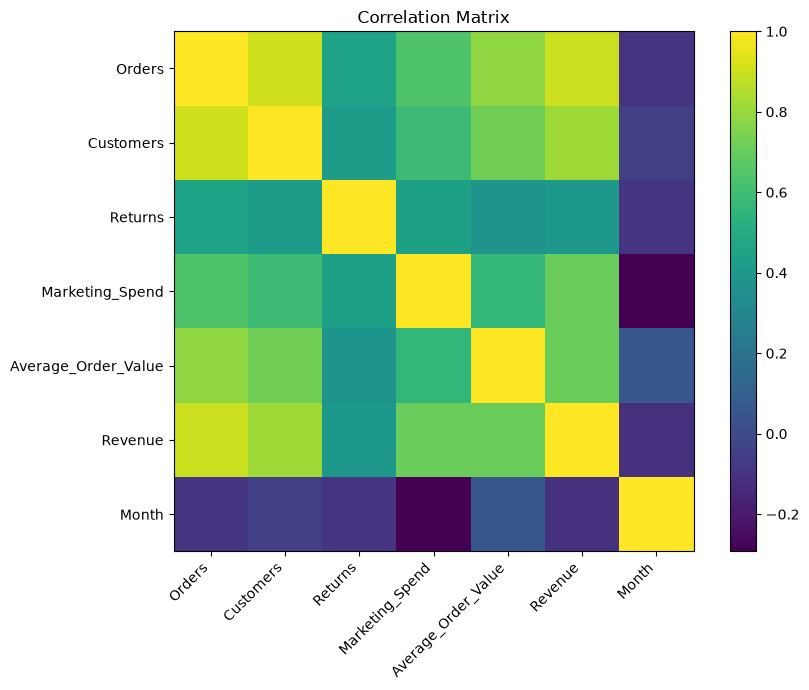

In [27]:
correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(9,7))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## EDA Summary

The exploratory analysis provides an understanding of historical
revenue patterns, monthly variations, relationships between orders
and revenue, and correlations among numerical variables. These
findings are used to prepare features for the predictive model.

## Feature Engineering

Feature engineering involves creating useful variables from the
historical data. Lag features are created from previous revenue values
so that the predictive model can use past revenue information when
estimating future revenue.

### Explanation

Lag features represent previous months' revenue, while the rolling
average represents the average revenue over the previous three months.
These features help the model learn patterns from historical revenue.

In [28]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

In [29]:
df["Revenue_Lag1"] = df["Revenue"].shift(1)

df["Revenue_Lag2"] = df["Revenue"].shift(2)

df["Revenue_Lag3"] = df["Revenue"].shift(3)

In [30]:
df["Revenue_Rolling3"] = (
    df["Revenue"]
    .shift(1)
    .rolling(3)
    .mean()
)

In [31]:
df = df.dropna().reset_index(drop=True)

df.head()

,Date,Orders,Customers,Returns,Marketing_Spend,Average_Order_Value,Revenue,Month,Year,Quarter,Revenue_Lag1,Revenue_Lag2,Revenue_Lag3,Revenue_Rolling3
0,2019-04-01,415,322,9,22689.56,766.70,189443.53,4,2019,2,160892.75,132435.50,135084.72,142804.323333
1,2019-05-01,349,266,12,19575.77,738.18,170476.97,5,2019,2,189443.53,160892.75,132435.50,160923.926667
2,2019-06-01,354,287,11,12225.68,761.42,156325.64,6,2019,2,170476.97,189443.53,160892.75,173604.416667
3,2019-07-01,371,275,8,15370.75,782.47,157021.18,7,2019,3,156325.64,170476.97,189443.53,172082.046667
4,2019-08-01,347,252,8,14469.66,825.63,131457.85,8,2019,3,157021.18,156325.64,170476.97,161274.596667


## Feature Selection

The selected features include sales activity, customer information,
marketing expenditure, time-based variables, and historical revenue
features. Revenue is used as the target variable that the models will
predict.

In [32]:
features = [
    "Orders",
    "Customers",
    "Returns",
    "Marketing_Spend",
    "Average_Order_Value",
    "Year",
    "Month",
    "Quarter",
    "Revenue_Lag1",
    "Revenue_Lag2",
    "Revenue_Lag3",
    "Revenue_Rolling3"
]

X = df[features]

y = df["Revenue"]

## Train-Test Split

Since the dataset contains historical time-based information, the data
is divided chronologically. The earlier 80% is used for training and
the most recent 20% is used for testing.

In [33]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 64
Testing data: 17


In [34]:
# Define input features and target variable

X = df[
    [
        "Orders",
        "Customers",
        "Returns",
        "Marketing_Spend",
        "Average_Order_Value"
    ]
]

y = df["Revenue"]

print("Features:", X.columns.tolist())
print("Target: Revenue")

Features: ['Orders', 'Customers', 'Returns', 'Marketing_Spend', 'Average_Order_Value']
Target: Revenue


## Linear Regression Model

Linear Regression is used as a baseline predictive model to estimate
revenue based on the selected historical features.

In [35]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [36]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression Results
-------------------------
MAE : 12693.21
RMSE: 14104.87
R²  : 0.2509


In [37]:
print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression Results
-------------------------
MAE : 12693.21
RMSE: 14104.87
R²  : 0.2509


## Random Forest Regression Model

Random Forest Regression is used as a second predictive model.
It combines multiple decision trees to capture nonlinear relationships
between the input features and revenue.

In [38]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

## Random Forest Evaluation

The Random Forest model is evaluated using MAE, RMSE, and R²
to measure its prediction performance on the test data.

In [39]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

In [40]:
print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest Results
---------------------
MAE : 12547.12
RMSE: 14229.7
R²  : 0.2375


## Model Comparison

The performance of Linear Regression and Random Forest Regression is
compared using MAE, RMSE, and R². Using the same evaluation metrics
allows the models to be compared consistently.

In [41]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    
    "MAE": [
        linear_mae,
        rf_mae
    ],
    
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    
    "R2": [
        linear_r2,
        rf_r2
    ]
})

results.round(2)

,Model,MAE,RMSE,R2
0,Linear Regression,12693.21,14104.87,0.25
1,Random Forest,12547.12,14229.70,0.24


## Actual vs Predicted Revenue

This visualization compares the actual revenue values with the revenue
predicted by the Random Forest model for the test period.

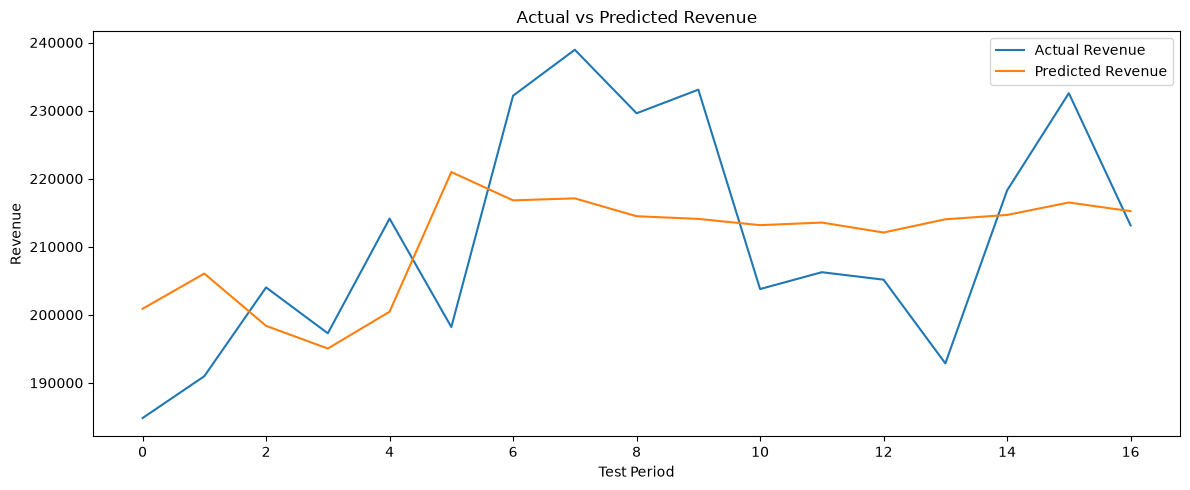

In [42]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Actual Revenue"
)

plt.plot(
    rf_predictions,
    label="Predicted Revenue"
)

plt.title("Actual vs Predicted Revenue")

plt.xlabel("Test Period")

plt.ylabel("Revenue")

plt.legend()

plt.tight_layout()

plt.show()

## Feature Importance

Feature importance shows which variables contributed most to the
Random Forest model's predictions.

In [43]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,Orders,0.623836
8,Revenue_Lag1,0.122242
3,Marketing_Spend,0.104917
1,Customers,0.051558
9,Revenue_Lag2,0.022043
11,Revenue_Rolling3,0.020549
4,Average_Order_Value,0.013997
10,Revenue_Lag3,0.013508
6,Month,0.011082
2,Returns,0.009161


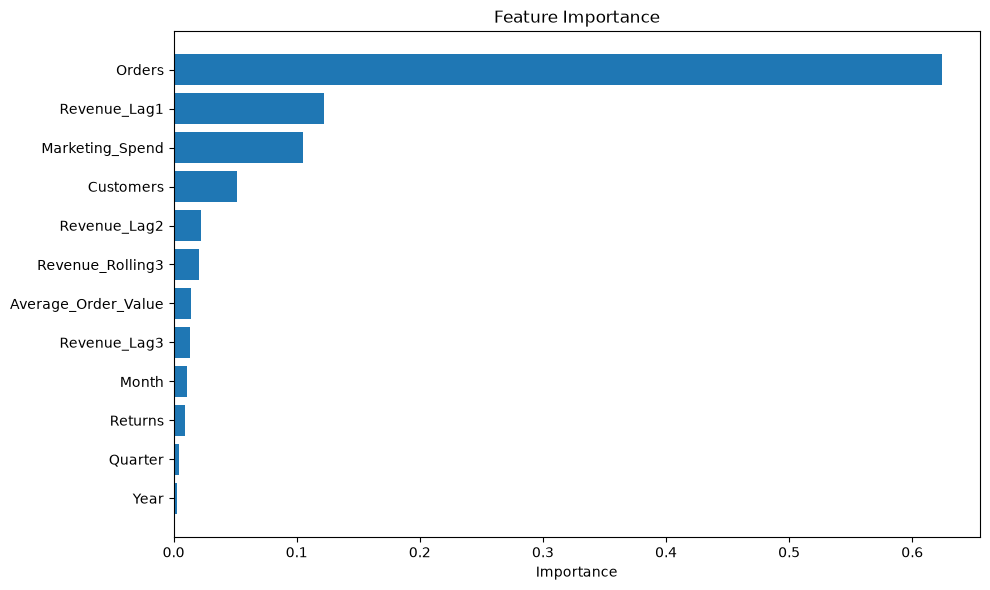

In [44]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

## Future Revenue Forecast

The trained Random Forest model is used to forecast revenue for the next
12 months. Previous revenue values are used as lag features so that the
model can use historical patterns when generating future predictions.

In [45]:
future_dates = pd.date_range(
    start=df["Date"].max() + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

future_dates

DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01',
               '2026-09-01', '2026-10-01', '2026-11-01', '2026-12-01'],
              dtype='datetime64[us]', freq='MS')

In [46]:
history = df[["Date", "Revenue"]].copy()

forecast = []

last_values = df.iloc[-1]

for date in future_dates:

    lag1 = history["Revenue"].iloc[-1]
    lag2 = history["Revenue"].iloc[-2]
    lag3 = history["Revenue"].iloc[-3]

    rolling3 = history["Revenue"].iloc[-3:].mean()

    future_row = pd.DataFrame([{
        "Orders": last_values["Orders"],
        "Customers": last_values["Customers"],
        "Returns": last_values["Returns"],
        "Marketing_Spend": last_values["Marketing_Spend"],
        "Average_Order_Value": last_values["Average_Order_Value"],
        "Year": date.year,
        "Month": date.month,
        "Quarter": date.quarter,
        "Revenue_Lag1": lag1,
        "Revenue_Lag2": lag2,
        "Revenue_Lag3": lag3,
        "Revenue_Rolling3": rolling3
    }])

    prediction = rf_model.predict(future_row[features])[0]

    forecast.append({
        "Date": date,
        "Forecast_Revenue": prediction
    })

    history = pd.concat([
        history,
        pd.DataFrame({
            "Date": [date],
            "Revenue": [prediction]
        })
    ], ignore_index=True)

In [47]:
forecast_df = pd.DataFrame(forecast)

forecast_df

,Date,Forecast_Revenue
0,2026-01-01,218084.46070
1,2026-02-01,218366.06430
2,2026-03-01,217779.90760
3,2026-04-01,218033.23015
4,2026-05-01,217809.61335
5,2026-06-01,217637.29790
6,2026-07-01,216714.23980
7,2026-08-01,216736.28465
8,2026-09-01,216736.28465
9,2026-10-01,216736.28465


## Historical Revenue and Future Forecast

This graph combines the historical revenue with the predicted revenue
for the next 12 months. It provides a visual representation of the
expected future revenue trend.

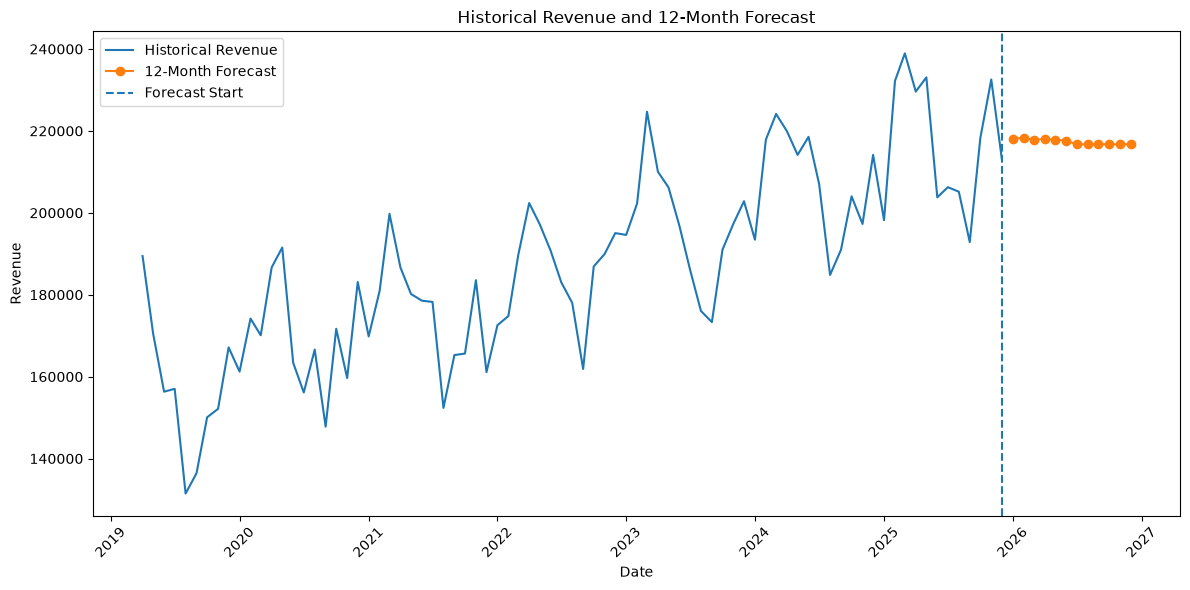

In [48]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Date"],
    df["Revenue"],
    label="Historical Revenue"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast_Revenue"],
    marker="o",
    label="12-Month Forecast"
)

plt.axvline(
    df["Date"].max(),
    linestyle="--",
    label="Forecast Start"
)

plt.title("Historical Revenue and 12-Month Forecast")

plt.xlabel("Date")
plt.ylabel("Revenue")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [49]:
forecast_df.to_csv(
    "future_revenue_forecast.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.


# Business Insights

- Historical revenue shows changes and trends over the analyzed period.
- Monthly analysis shows variations in revenue across different months.
- The relationship between orders and revenue provides useful information
  about sales performance.
- Historical revenue features were used to improve predictive modeling.
- Linear Regression and Random Forest Regression were evaluated using
  MAE, RMSE, and R².
- The Actual vs Predicted graph shows the model's performance on the
  test period.
- Feature importance identifies the variables that contributed most to
  the Random Forest predictions.
- The 12-month forecast provides an estimate of future revenue trends.
- Revenue forecasting can support sales planning, budgeting, marketing,
  and inventory-related decisions.

# Conclusion

This project analyzed historical sales data and developed predictive
models to forecast future revenue. The dataset was cleaned and
preprocessed before performing exploratory data analysis and feature
engineering.

Linear Regression and Random Forest Regression were trained and
evaluated using MAE, RMSE, and R². The models were further analyzed
using actual-versus-predicted visualizations and feature importance.

Finally, the trained model was used to generate a 12-month revenue
forecast. The project demonstrates how historical data and machine
learning can be applied to predictive modeling, trend analysis, and
data-driven forecasting.